# 05 - Optimisation des hyperparamètres et du seuil métier

## Objectif du notebook

Dans cette étape, l’objectif est d’optimiser le modèle retenu à l’étape précédente afin de réduire le coût métier.

Le problème métier est un problème de scoring crédit.  
La classe positive `TARGET = 1` correspond à un client en défaut de paiement.

Dans ce contexte, une erreur de type faux négatif est plus grave qu’une erreur de type faux positif :

- **FN** : client risqué prédit comme non risqué ;
- **FP** : bon client prédit comme risqué.

L’objectif est donc de minimiser un coût métier personnalisé, et non simplement de maximiser l’accuracy.

## Rappel des prérequis de l'étape

Les prérequis sont remplis :

| Prérequis | Statut |
|---|---|
| Avoir entraîné plusieurs modèles | Oui |
| Avoir comparé leurs performances de base | Oui |
| Avoir compris la notion de coût d’erreur | Oui |
| Avoir défini une fonction de coût métier | Oui |

À l’étape précédente, plusieurs familles de modèles ont été comparées avec une validation croisée stratifiée :

- Logistic Regression ;
- Random Forest ;
- LightGBM ;
- XGBoost ;
- MLPClassifier.

Le meilleur candidat était XGBoost, car il obtenait le coût métier moyen le plus faible.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import mlflow
import pandas as pd
from IPython.display import Image, display


# Gestion robuste du chemin projet :
# - si le notebook est exécuté depuis le dossier notebooks, on remonte d'un niveau ;
# - sinon, on considère que le dossier courant est déjà la racine du projet.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

MLFLOW_DB_PATH = PROJECT_ROOT / "mlflow.db"
mlflow.set_tracking_uri(f"sqlite:///{MLFLOW_DB_PATH}")

print("Racine projet :", PROJECT_ROOT)
print("Tracking URI MLflow :", mlflow.get_tracking_uri())

Racine projet : /Users/vincentdesmouceaux/dev/P6_MLOps_credit_scoring
Tracking URI MLflow : sqlite:////Users/vincentdesmouceaux/dev/P6_MLOps_credit_scoring/mlflow.db


## Fonction de coût métier

La métrique principale utilisée pour sélectionner le modèle est le coût métier :

`business_cost = 10 × FN + 1 × FP`

Ce choix signifie qu’un faux négatif coûte 10 fois plus cher qu’un faux positif.

Dans le contexte crédit :

- un **faux négatif** correspond à un client risqué qui obtient un crédit ;
- un **faux positif** correspond à un bon client refusé à tort.

Le modèle doit donc réduire en priorité les faux négatifs, sans exploser le nombre de faux positifs.

In [2]:
FN_COST = 10
FP_COST = 1

print(f"Coût d'un faux négatif : {FN_COST}")
print(f"Coût d'un faux positif : {FP_COST}")
print("Formule : business_cost = 10 * FN + 1 * FP")

Coût d'un faux négatif : 10
Coût d'un faux positif : 1
Formule : business_cost = 10 * FN + 1 * FP


## Récupération des expériences MLflow

On récupère maintenant les runs MLflow :

- `P6_credit_scoring_cross_validation` pour le meilleur modèle de base ;
- `P6_credit_scoring_optimization` pour le modèle optimisé avec Optuna.

In [3]:
def get_experiment_runs(experiment_name: str) -> pd.DataFrame:
    experiment = mlflow.get_experiment_by_name(experiment_name)

    if experiment is None:
        raise ValueError(f"Expérience MLflow introuvable : {experiment_name}")

    runs = mlflow.search_runs(
        experiment_ids=[experiment.experiment_id],
        order_by=["start_time DESC"],
    )

    return runs


cv_runs = get_experiment_runs("P6_credit_scoring_cross_validation")
optimization_runs = get_experiment_runs("P6_credit_scoring_optimization")

print("Nombre de runs CV :", len(cv_runs))
print("Nombre de runs optimisation :", len(optimization_runs))

Nombre de runs CV : 17
Nombre de runs optimisation : 1


## Résultats de base avant optimisation

Le meilleur modèle de l’étape 3 était XGBoost.

On récupère son run dans l’expérience de validation croisée.

In [4]:
# Sélection du run XGBoost de validation croisée
xgb_base_runs = cv_runs[
    (cv_runs["params.model_name"] == "xgboost_weighted_cv")
    | (cv_runs["tags.mlflow.runName"] == "xgboost_weighted_cv")
].copy()

if xgb_base_runs.empty:
    raise ValueError("Aucun run XGBoost trouvé dans l'expérience de validation croisée.")

xgb_base_run = xgb_base_runs.sort_values(by="start_time", ascending=False).iloc[0]

base_summary = pd.DataFrame(
    {
        "metric": [
            "mean_accuracy",
            "mean_precision",
            "mean_recall",
            "mean_f1_score",
            "mean_roc_auc",
            "mean_business_cost",
            "std_business_cost",
        ],
        "value": [
            xgb_base_run.get("metrics.mean_accuracy"),
            xgb_base_run.get("metrics.mean_precision"),
            xgb_base_run.get("metrics.mean_recall"),
            xgb_base_run.get("metrics.mean_f1_score"),
            xgb_base_run.get("metrics.mean_roc_auc"),
            xgb_base_run.get("metrics.mean_business_cost"),
            xgb_base_run.get("metrics.std_business_cost"),
        ],
    }
)

base_summary

,metric,value
0,mean_accuracy,0.748125
1,mean_precision,0.187761
2,mean_recall,0.637347
3,mean_f1_score,0.290064
4,mean_roc_auc,0.768847
5,mean_business_cost,13742.666667
6,std_business_cost,290.775400


## Optimisation avec Optuna

L’étape 4 utilise **Optuna** pour optimiser les hyperparamètres de XGBoost.

L’objectif d’optimisation n’est pas l’accuracy, mais le coût métier moyen obtenu en validation croisée.

Pour chaque essai Optuna :

1. un jeu d’hyperparamètres XGBoost est proposé ;
2. le modèle est évalué avec `StratifiedKFold` ;
3. plusieurs seuils de décision sont testés ;
4. le seuil qui minimise le coût métier est retenu ;
5. Optuna cherche à minimiser le coût métier moyen.

In [5]:
# Sélection du run final d'optimisation
optimized_runs = optimization_runs[
    optimization_runs["tags.mlflow.runName"] == "xgboost_optuna_threshold_optimized"
].copy()

if optimized_runs.empty:
    raise ValueError("Aucun run final d'optimisation XGBoost trouvé dans MLflow.")

optimized_run = optimized_runs.sort_values(by="start_time", ascending=False).iloc[0]

print("Run optimisé sélectionné :")
print("run_id :", optimized_run["run_id"])
print("run_name :", optimized_run["tags.mlflow.runName"])

Run optimisé sélectionné :
run_id : 5cd584a85f1d4eecaa012636815f3f24
run_name : xgboost_optuna_threshold_optimized


## Meilleurs hyperparamètres trouvés

Les meilleurs hyperparamètres retenus par Optuna sont récupérés depuis MLflow.

In [6]:
best_param_columns = [
    column
    for column in optimized_run.index
    if column.startswith("params.best_")
]

best_params = (
    optimized_run[best_param_columns]
    .dropna()
    .rename_axis("parameter")
    .reset_index(name="value")
)

best_params["parameter"] = best_params["parameter"].str.replace("params.best_", "", regex=False)

best_params

,parameter,value
0,subsample,0.7732007623709093
1,threshold,0.4500000000000001
2,min_child_weight,28
3,random_state,42
4,tree_method,hist
5,max_depth,4
6,learning_rate,0.0461430872606226
7,reg_alpha,0.0009488668843401602
8,eval_metric,auc
9,colsample_bytree,0.9509791045523027


## Seuil métier optimal

Le seuil par défaut d’un modèle de classification est souvent `0.50`.

Cependant, ce seuil n’est pas forcément adapté au contexte métier.  
Ici, les faux négatifs coûtent beaucoup plus cher que les faux positifs.

Le seuil de décision a donc été testé entre `0.10` et `0.90`.

Le meilleur seuil trouvé est :

`threshold = 0.45`

Cela signifie qu’un client est classé comme risqué dès que sa probabilité de défaut est supérieure ou égale à 45 %.

In [7]:
optimization_summary = pd.DataFrame(
    {
        "metric": [
            "best_threshold",
            "best_mean_accuracy",
            "best_mean_precision",
            "best_mean_recall",
            "best_mean_f1_score",
            "best_mean_roc_auc",
            "best_mean_business_cost",
            "best_std_business_cost",
            "best_mean_business_cost_per_client",
            "best_mean_tn",
            "best_mean_fp",
            "best_mean_fn",
            "best_mean_tp",
        ],
        "value": [
            optimized_run.get("params.best_threshold"),
            optimized_run.get("metrics.best_mean_accuracy"),
            optimized_run.get("metrics.best_mean_precision"),
            optimized_run.get("metrics.best_mean_recall"),
            optimized_run.get("metrics.best_mean_f1_score"),
            optimized_run.get("metrics.best_mean_roc_auc"),
            optimized_run.get("metrics.best_mean_business_cost"),
            optimized_run.get("metrics.best_std_business_cost"),
            optimized_run.get("metrics.best_mean_business_cost_per_client"),
            optimized_run.get("metrics.best_mean_tn"),
            optimized_run.get("metrics.best_mean_fp"),
            optimized_run.get("metrics.best_mean_fn"),
            optimized_run.get("metrics.best_mean_tp"),
        ],
    }
)

optimization_summary

,metric,value
0,best_threshold,0.4500000000000001
1,best_mean_accuracy,0.741087
2,best_mean_precision,0.186061
3,best_mean_recall,0.653915
4,best_mean_f1_score,0.289691
5,best_mean_roc_auc,0.771288
6,best_mean_business_cost,13609.333333
7,best_std_business_cost,442.15985
8,best_mean_business_cost_per_client,0.51035
9,best_mean_tn,18354.666667


## Comparaison avant / après optimisation

On compare maintenant :

- XGBoost avant optimisation, issu de l’étape 3 ;
- XGBoost optimisé avec Optuna et seuil métier ajusté.

In [8]:
comparison = pd.DataFrame(
    [
        {
            "version": "XGBoost étape 3",
            "threshold": 0.50,
            "mean_accuracy": xgb_base_run.get("metrics.mean_accuracy"),
            "mean_precision": xgb_base_run.get("metrics.mean_precision"),
            "mean_recall": xgb_base_run.get("metrics.mean_recall"),
            "mean_f1_score": xgb_base_run.get("metrics.mean_f1_score"),
            "mean_roc_auc": xgb_base_run.get("metrics.mean_roc_auc"),
            "mean_business_cost": xgb_base_run.get("metrics.mean_business_cost"),
            "std_business_cost": xgb_base_run.get("metrics.std_business_cost"),
        },
        {
            "version": "XGBoost optimisé étape 4",
            "threshold": float(optimized_run.get("params.best_threshold")),
            "mean_accuracy": optimized_run.get("metrics.best_mean_accuracy"),
            "mean_precision": optimized_run.get("metrics.best_mean_precision"),
            "mean_recall": optimized_run.get("metrics.best_mean_recall"),
            "mean_f1_score": optimized_run.get("metrics.best_mean_f1_score"),
            "mean_roc_auc": optimized_run.get("metrics.best_mean_roc_auc"),
            "mean_business_cost": optimized_run.get("metrics.best_mean_business_cost"),
            "std_business_cost": optimized_run.get("metrics.best_std_business_cost"),
        },
    ]
)

comparison

,version,threshold,mean_accuracy,mean_precision,mean_recall,mean_f1_score,mean_roc_auc,mean_business_cost,std_business_cost
0,XGBoost étape 3,0.50,0.748125,0.187761,0.637347,0.290064,0.768847,13742.666667,290.77540
1,XGBoost optimisé étape 4,0.45,0.741087,0.186061,0.653915,0.289691,0.771288,13609.333333,442.15985


In [9]:
base_cost = float(xgb_base_run.get("metrics.mean_business_cost"))
optimized_cost = float(optimized_run.get("metrics.best_mean_business_cost"))

gain = base_cost - optimized_cost
gain_percent = gain / base_cost * 100

print(f"Coût métier avant optimisation : {base_cost:.2f}")
print(f"Coût métier après optimisation : {optimized_cost:.2f}")
print(f"Gain absolu : {gain:.2f}")
print(f"Gain relatif : {gain_percent:.2f} %")

Coût métier avant optimisation : 13742.67
Coût métier après optimisation : 13609.33
Gain absolu : 133.33
Gain relatif : 0.97 %


## Courbe coût métier vs seuil

Le point de vigilance principal de cette étape est de ne pas conserver le seuil `0.50` sans justification.

La courbe suivante permet de visualiser le coût métier moyen en fonction du seuil de décision.

Le seuil retenu est celui qui minimise le coût métier.

In [10]:
threshold_curve_path = PROJECT_ROOT / "reports" / "optimization" / "xgboost_optimized_threshold_curve.csv"

if threshold_curve_path.exists():
    threshold_curve = pd.read_csv(threshold_curve_path)
    display(threshold_curve.sort_values(by="threshold"))
else:
    threshold_curve = None
    print(f"Fichier introuvable : {threshold_curve_path}")

,threshold,mean_accuracy,std_accuracy,mean_precision,std_precision,mean_recall,std_recall,mean_f1_score,std_f1_score,mean_roc_auc,...,mean_fp,std_fp,mean_fn,std_fn,mean_tp,std_tp,mean_business_cost,std_business_cost,mean_business_cost_per_client,std_business_cost_per_client
16,0.10,0.185375,0.005841,0.089038,0.000425,0.984825,0.001937,0.163310,0.000688,0.771288,...,21690.666667,160.232123,32.666667,4.163332,2120.000000,4.582576,22017.333333,119.558912,0.825650,0.004468
13,0.15,0.289400,0.009041,0.098735,0.000788,0.959894,0.004472,0.179052,0.001228,0.771288,...,18863.000000,250.449596,86.333333,9.609024,2066.333333,10.066446,19726.333333,164.037597,0.739737,0.006136
10,0.20,0.389913,0.007770,0.110015,0.000664,0.924898,0.008880,0.196637,0.000999,0.771288,...,16107.333333,224.259522,161.666667,19.087518,1991.000000,19.467922,17724.000000,104.110518,0.664650,0.003893
8,0.25,0.480388,0.003631,0.122727,0.000940,0.884327,0.013310,0.215539,0.001803,0.771288,...,13607.333333,121.079863,249.000000,28.583212,1903.666667,29.143324,16097.333333,188.918854,0.603650,0.007098
5,0.30,0.561887,0.001213,0.136956,0.001148,0.835087,0.009108,0.235319,0.002041,0.771288,...,11328.000000,38.742741,355.000000,19.519221,1797.666667,20.033306,14878.000000,176.553108,0.557925,0.006632
3,0.35,0.631237,0.003721,0.151832,0.002762,0.777948,0.010884,0.254075,0.004430,0.771288,...,9355.666667,80.208063,478.000000,23.302360,1674.666667,23.860707,14135.666667,298.384539,0.530088,0.011201
1,0.40,0.690825,0.004272,0.168329,0.004053,0.718022,0.013026,0.272721,0.006242,0.771288,...,7637.666667,88.895069,607.000000,27.874720,1545.666667,28.448784,13707.666667,358.025604,0.514038,0.013437
0,0.45,0.741087,0.005009,0.186061,0.006123,0.653915,0.016271,0.289691,0.009002,0.771288,...,6159.333333,100.922412,745.000000,34.828150,1407.666667,35.388322,13609.333333,442.159850,0.510350,0.016592
2,0.50,0.784800,0.003647,0.205477,0.005209,0.580983,0.012805,0.303578,0.007220,0.771288,...,4836.666667,86.193581,902.000000,27.404379,1250.666667,27.790886,13856.666667,308.365584,0.519625,0.011573
4,0.55,0.821087,0.002631,0.228321,0.002105,0.510995,0.005413,0.315602,0.001107,0.771288,...,3718.333333,81.733306,1052.666667,11.930353,1100.000000,11.357817,14245.000000,42.035699,0.534187,0.001565


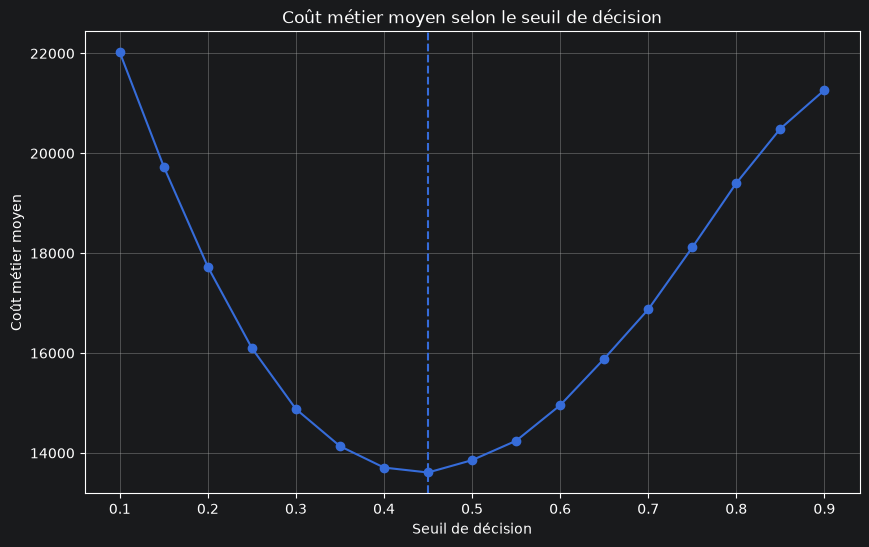

Meilleur seuil : 0.45
Meilleur coût métier moyen : 13609.33


In [11]:
if threshold_curve is not None:
    plot_df = threshold_curve.sort_values(by="threshold")

    best_threshold = float(optimized_run.get("params.best_threshold"))
    best_cost = float(optimized_run.get("metrics.best_mean_business_cost"))

    plt.figure(figsize=(10, 6))
    plt.plot(
        plot_df["threshold"],
        plot_df["mean_business_cost"],
        marker="o",
    )
    plt.axvline(best_threshold, linestyle="--")
    plt.xlabel("Seuil de décision")
    plt.ylabel("Coût métier moyen")
    plt.title("Coût métier moyen selon le seuil de décision")
    plt.grid(True)
    plt.show()

    print(f"Meilleur seuil : {best_threshold:.2f}")
    print(f"Meilleur coût métier moyen : {best_cost:.2f}")

## Affichage de la figure sauvegardée

Le script d’optimisation sauvegarde également une figure dans le dossier `reports/figures`.

Cette figure peut être utilisée dans la présentation ou le rapport.

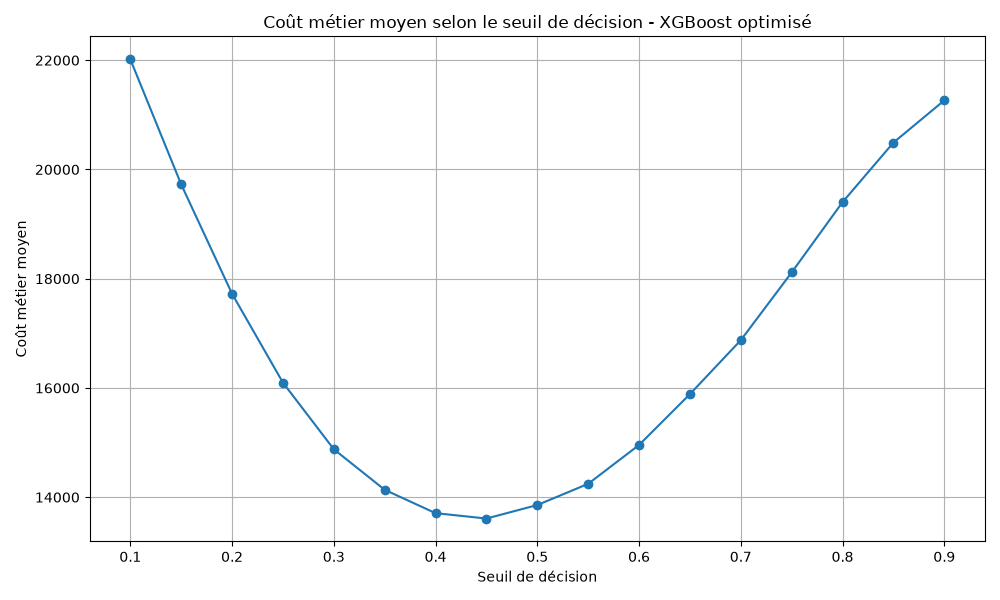

In [12]:
figure_path = PROJECT_ROOT / "reports" / "figures" / "xgboost_optimized_cost_vs_threshold.png"

if figure_path.exists():
    display(Image(filename=str(figure_path)))
else:
    print(f"Figure introuvable : {figure_path}")

## Interprétation des résultats

Le modèle optimisé obtient les résultats suivants :

| Élément | Résultat |
|---|---:|
| Modèle | XGBoost |
| Outil d’optimisation | Optuna |
| Stratégie de validation | StratifiedKFold |
| Nombre de folds | 3 |
| Meilleur seuil métier | 0.45 |
| Coût métier moyen | 13609.33 |
| Recall moyen | 0.6539 |
| AUC moyenne | 0.7713 |

Le seuil optimal est inférieur à `0.50`.  
C’est cohérent avec le contexte métier, car les faux négatifs sont les erreurs les plus coûteuses.

En abaissant le seuil, le modèle détecte davantage de clients risqués, ce qui permet de réduire le coût métier global.

## Vérification des points de vigilance

| Point de vigilance | Réponse apportée |
|---|---|
| Ne pas garder le seuil 0.5 sans justification | Le seuil optimal est recherché entre 0.10 et 0.90 |
| Ne pas optimiser uniquement l’AUC ou l’accuracy | L’objectif principal est le coût métier |
| Ne pas oublier le coût FN vs FP | La fonction de coût pondère FN à 10 et FP à 1 |
| Ne pas oublier la courbe coût vs seuil | La courbe est tracée et sauvegardée |
| Ne pas choisir un modèle sans tester sa robustesse | Le modèle est réévalué avec StratifiedKFold |

## Conclusion de l'étape 4

L’optimisation des hyperparamètres de XGBoost a été réalisée avec Optuna.

L’objectif d’optimisation n’était pas l’accuracy, mais le coût métier personnalisé :

`business_cost = 10 × FN + 1 × FP`

Pour chaque essai Optuna, le modèle a été évalué avec une validation croisée stratifiée.  
Plusieurs seuils de décision, de `0.10` à `0.90`, ont été testés afin d’identifier le seuil minimisant le coût métier.

Le meilleur modèle obtenu utilise un seuil de décision de `0.45`.  
Ce seuil est inférieur au seuil standard de `0.50`, ce qui est cohérent avec le contexte métier : les faux négatifs sont plus coûteux que les faux positifs.

Après optimisation, XGBoost obtient un coût métier moyen de `13609.33`, contre environ `13742.67` avant optimisation.

Le modèle XGBoost optimisé avec seuil métier ajusté est donc retenu comme modèle candidat final.